# This notebook contains the EDA of the financial fraud dataset from Kaggle

In [19]:
#%pip install -r ../requirements.txt -q

In [20]:
import kagglehub
import os
import shutil

# Create the data/raw directory if it doesn't exist
os.makedirs("../data/raw", exist_ok=True)

path = kagglehub.dataset_download("sriharshaeedala/financial-fraud-detection-dataset")
print("Dataset downloaded to:", path)

target_dir = "../data/raw/financial-fraud-detection-dataset"
if os.path.exists(target_dir):
    shutil.rmtree(target_dir)  
shutil.copytree(path, target_dir)
print(f"Dataset copied to: {target_dir}")

path = target_dir

Dataset downloaded to: /Users/angjiayi/.cache/kagglehub/datasets/sriharshaeedala/financial-fraud-detection-dataset/versions/1
Dataset copied to: ../data/raw/financial-fraud-detection-dataset
Dataset copied to: ../data/raw/financial-fraud-detection-dataset


In [21]:
import pandas as pd
import os

csv_file = os.path.join(path, "Synthetic_Financial_datasets_log.csv")
print(f"Looking for file at: {csv_file}")

df = pd.read_csv(csv_file)
print("Shape:", df.shape)
print(df.head())


Looking for file at: ../data/raw/financial-fraud-detection-dataset/Synthetic_Financial_datasets_log.csv
Shape: (6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        

In [28]:
# One hot encoding
df_encode = df.drop(columns=['nameOrig', 'nameDest'])
df_encode['type'] = df_encode['type'].astype('category').cat.codes


# Correlation:

**Correlation** measures the linear relationship between two variables:
- Range: -1 to +1
- +1 = perfect positive correlation
- 0 = no linear relationship  
- -1 = perfect negative correlation
- Only considers **pairwise** relationships (low pairwise correlations == each pair look independent)

In [29]:
corr = df_encode.corr(numeric_only=True)

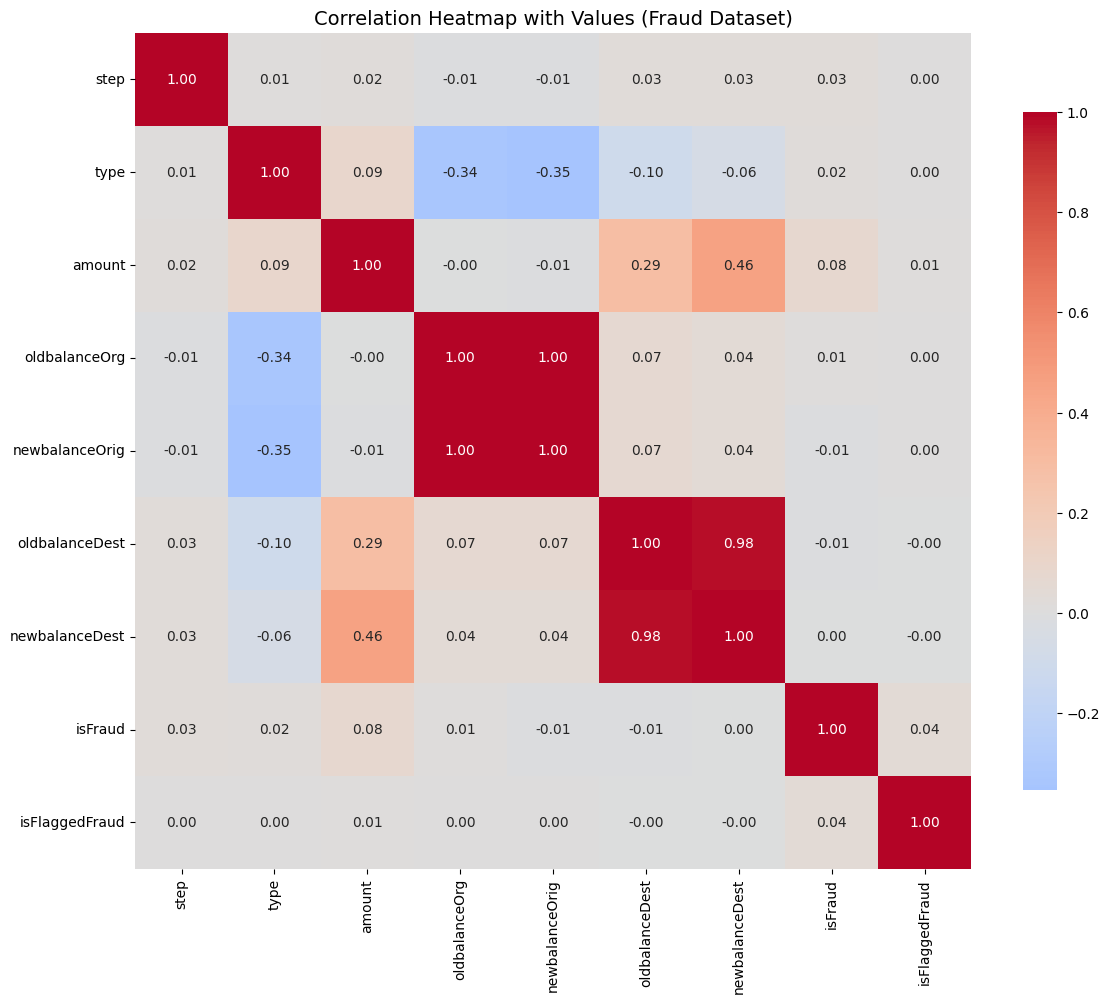

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', 
            square=True, cbar_kws={'shrink': 0.8})
plt.title("Correlation Heatmap with Values (Fraud Dataset)", fontsize=14)
plt.tight_layout()
plt.show()

# Collinearity:

**Collinearity** (Multicollinearity) refers to when predictor variables are linearly dependent:
- Measured using **VIF (Variance Inflation Factor)**
- VIF > 5: Moderate collinearity
- VIF > 10: High collinearity (problematic for modeling)
- Considers **multiple variables** simultaneously
- Can exist even when pairwise correlations are low!

In [30]:
# Calculate VIF (Variance Inflation Factor) for Collinearity Detection
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# Select numeric features for VIF calculation (excluding target variable 'isFraud')
numeric_features = df_encode.select_dtypes(include=[np.number]).columns.tolist()
if 'isFraud' in numeric_features:
    numeric_features.remove('isFraud')

# Create feature matrix for VIF calculation
X = df_encode[numeric_features].dropna()

# Calculate VIF for each feature
vif_data = []
for i in range(X.shape[1]):
    vif_value = variance_inflation_factor(X.values, i)
    vif_data.append({'Feature': X.columns[i], 'VIF': vif_value})

vif_df = pd.DataFrame(vif_data)
vif_df = vif_df.sort_values('VIF', ascending=False)

print("Variance Inflation Factor (VIF) - Collinearity Detection:")
print("="*50)
for _, row in vif_df.iterrows():
    status = ""
    if row['VIF'] > 10:
        status = "HIGH COLLINEARITY"
    elif row['VIF'] > 5:
        status = "MODERATE COLLINEARITY"
    else:
        status = "LOW COLLINEARITY"
    
    print(f"{row['Feature']:<15}: {row['VIF']:>8.2f} {status}")

Variance Inflation Factor (VIF) - Collinearity Detection:
newbalanceOrig :   483.73 HIGH COLLINEARITY
oldbalanceOrg  :   480.23 HIGH COLLINEARITY
newbalanceDest :    83.58 HIGH COLLINEARITY
oldbalanceDest :    72.10 HIGH COLLINEARITY
amount         :     4.02 LOW COLLINEARITY
step           :     2.24 LOW COLLINEARITY
type           :     2.08 LOW COLLINEARITY
isFlaggedFraud :     1.00 LOW COLLINEARITY


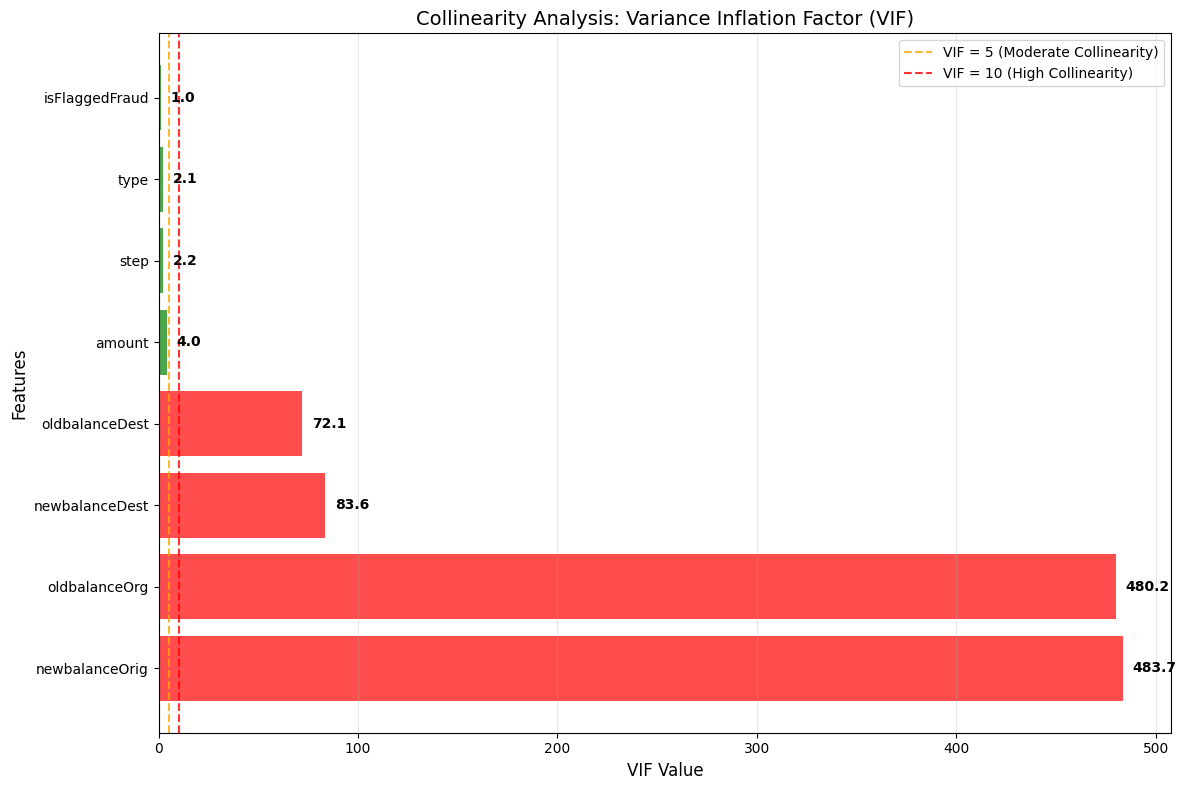


VIF Interpretation:
VIF < 5:  Low collinearity (good for modeling)
5 ≤ VIF < 10: Moderate collinearity (monitor)
VIF ≥ 10: High collinearity (consider removing)

Collinearity shows how well each variable can be predicted
from ALL other variables combined (multivariate relationship)


In [31]:
# Create VIF visualization for Collinearity
plt.figure(figsize=(12, 8))

# VIF Bar Chart
vif_colors = ['red' if x > 10 else 'orange' if x > 5 else 'green' for x in vif_df['VIF']]
bars = plt.barh(vif_df['Feature'], vif_df['VIF'], color=vif_colors, alpha=0.7)

# Add reference lines
plt.axvline(x=5, color='orange', linestyle='--', alpha=0.8, label='VIF = 5 (Moderate Collinearity)')
plt.axvline(x=10, color='red', linestyle='--', alpha=0.8, label='VIF = 10 (High Collinearity)')

# Add VIF values on bars
for i, (bar, vif_val) in enumerate(zip(bars, vif_df['VIF'])):
    plt.text(vif_val + max(vif_df['VIF']) * 0.01, bar.get_y() + bar.get_height()/2, 
            f'{vif_val:.1f}', va='center', fontsize=10, fontweight='bold')

plt.xlabel('VIF Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Collinearity Analysis: Variance Inflation Factor (VIF)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nVIF Interpretation:")
print("="*40)
print("VIF < 5:  Low collinearity (good for modeling)")
print("5 ≤ VIF < 10: Moderate collinearity (monitor)")  
print("VIF ≥ 10: High collinearity (consider removing)")
print("\nCollinearity shows how well each variable can be predicted")
print("from ALL other variables combined (multivariate relationship)")

# Collinearity and Correlation Plot

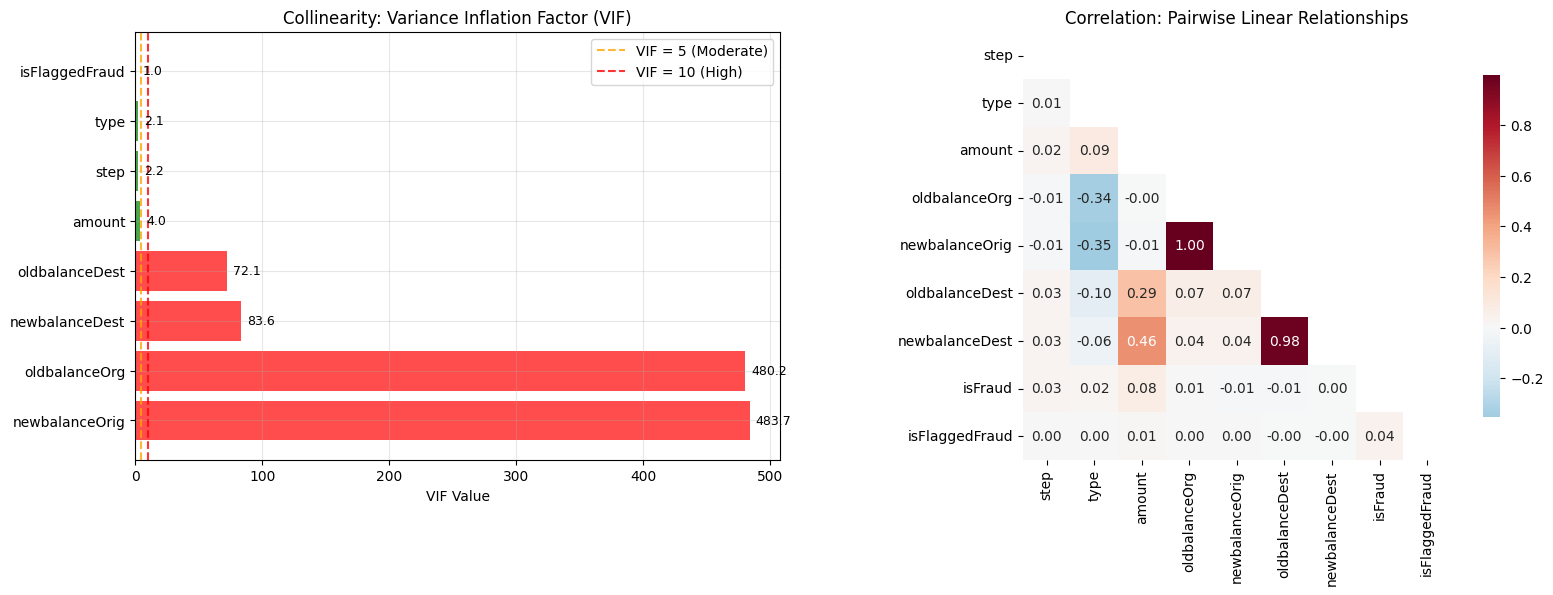


Comparison Summary:
Left plot (VIF): Shows multivariate collinearity - how well each variable
                 can be predicted from ALL other variables combined
Right plot (Correlation): Shows pairwise relationships - how each variable
                         relates to just ONE other variable at a time


In [32]:
# Create comparison plots: Correlation vs Collinearity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: VIF Bar Chart (Collinearity)
vif_colors = ['red' if x > 10 else 'orange' if x > 5 else 'green' for x in vif_df['VIF']]
bars = axes[0].barh(vif_df['Feature'], vif_df['VIF'], color=vif_colors, alpha=0.7)
axes[0].axvline(x=5, color='orange', linestyle='--', alpha=0.8, label='VIF = 5 (Moderate)')
axes[0].axvline(x=10, color='red', linestyle='--', alpha=0.8, label='VIF = 10 (High)')
axes[0].set_xlabel('VIF Value')
axes[0].set_title('Collinearity: Variance Inflation Factor (VIF)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add VIF values on bars
for i, (bar, vif_val) in enumerate(zip(bars, vif_df['VIF'])):
    axes[0].text(vif_val + max(vif_df['VIF']) * 0.01, bar.get_y() + bar.get_height()/2, 
                f'{vif_val:.1f}', va='center', fontsize=9)

# Plot 2: Correlation Heatmap (clean version)
mask_upper = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask_upper, annot=True, cmap='RdBu_r', center=0, 
            square=True, ax=axes[1], cbar_kws={'shrink': 0.8}, fmt='.2f')
axes[1].set_title('Correlation: Pairwise Linear Relationships')

plt.tight_layout()
plt.show()

print("\nComparison Summary:")
print("="*50)
print("Left plot (VIF): Shows multivariate collinearity - how well each variable")
print("                 can be predicted from ALL other variables combined")
print("Right plot (Correlation): Shows pairwise relationships - how each variable") 
print("                         relates to just ONE other variable at a time")